# ML libraries versions and CUDA check

In [1]:
import pytorch_lightning as pl
import torch

print("Lightning version:", pl.__version__)
print("Torch version:", torch.__version__)
print("CUDA is available:", torch.cuda.is_available())

Lightning version: 2.6.0
Torch version: 2.9.1+cu128
CUDA is available: True


# Libraries needed

In [3]:
import os
import random
from PIL import Image

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger

import torch
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms, datasets
from torchvision import models

from torchmetrics import Accuracy, F1Score, Precision, Recall, ConfusionMatrix

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Project: Malaria Cell Classification

## 1. Objectives
The goal of this project is to develop a Deep Learning model to classify single-cell images of erythrocytes.
* **Problem:** Binary classification (Healthy vs. Infected).
* **Architecture:** Convolutional Neural Network (CNN).
* **Input:** RGB Microscopic images (varying sizes).
* **Metrics:** Accuracy, Confusion Matrix on a reserved test set.

## 2. Dataset Visualization
Before training, we visualize random samples from the `train` dataset to understand the data characteristics.

In [4]:
def visualize_samples(base_path='./malaria_dataset/train', num_samples=3):
    """
    Visualizes random samples from 'positive' and 'negative' classes.
    """
    classes = ['positive', 'negative']
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(12, 8))
    
    for i, cls in enumerate(classes):
        # Path to the specific class folder
        cls_path = os.path.join(base_path, cls)
        
        # Get all image files
        all_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Select random samples
        selected_files = random.sample(all_files, num_samples)
        
        for j, file_name in enumerate(selected_files):
            img_path = os.path.join(cls_path, file_name)
            img = Image.open(img_path)
            
            # Plotting
            ax = axes[i, j]
            ax.imshow(img)
            ax.set_title(f"Class: {cls}\n{img.size}") # Show class and resolution
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization
# Make sure the path matches your unzipped dataset location
if os.path.exists('./malaria_dataset/train'):
    visualize_samples('./malaria_dataset/train')
else:
    print("Dataset path not found. Please check the directory structure.")

Dataset path not found. Please check the directory structure.


## 3. Creating data module

In [5]:
class MalariaDataModule(pl.LightningDataModule):
    def __init__(self, data_dir: str = "./malaria_dataset", batch_size: int = 32, img_size: int = 128):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.img_size = img_size
        
        # Path to the training folder (contains 'positive' and 'negative' subfolders)
        self.train_dir = os.path.join(data_dir, 'train')

        # 1. Define Transforms
        
        # Training Transforms (With Augmentation)
        # We use this to artificially increase dataset diversity and prevent overfitting.
        self.train_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomRotation(20),       # Rotate +/- 20 degrees
            transforms.RandomHorizontalFlip(),   # Mirror image
            transforms.RandomVerticalFlip(),     # Flip upside down (cells have no orientation)
            transforms.ColorJitter(brightness=0.1, contrast=0.1), # Simulate lighting variations
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        # Evaluation Transforms (Clean)
        # Used for Validation and Test sets. No random changes, just resizing and normalizing.
        self.eval_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def setup(self, stage=None):
        """
        Splits the data into Train/Val/Test and applies appropriate transformations.
        Approach: We use two separate ImageFolder objects (one augmented, one clean)
        and map indices to them using Subsets.
        """
        if stage == "fit" or stage == "test" or stage is None:
            # STEP 1: Load directory structure to get the total number of images
            # We use a dummy dataset just to read filenames and length
            dummy_ds = datasets.ImageFolder(self.train_dir)
            n_total = len(dummy_ds)
            
            # STEP 2: Calculate split sizes (80% Train, 10% Val, 10% Test)
            train_len = int(0.8 * n_total)
            val_len = int(0.1 * n_total)
            # The rest goes to test
            
            # STEP 3: Generate random indices for the split
            # We use a fixed seed generator for reproducibility
            g = torch.Generator().manual_seed(42)
            indices = torch.randperm(n_total, generator=g).tolist()
            
            train_idx = indices[:train_len]
            val_idx = indices[train_len : train_len + val_len]
            test_idx = indices[train_len + val_len :]

            # STEP 4: Create TWO separate dataset objects with different transforms
            # Dataset A: With Augmentation (for Training)
            train_dataset_obj = datasets.ImageFolder(self.train_dir, transform=self.train_transform)
            # Dataset B: Without Augmentation (for Validation/Testing)
            eval_dataset_obj = datasets.ImageFolder(self.train_dir, transform=self.eval_transform)

            # STEP 5: Create Subsets by mapping indices to the correct dataset object
            self.train_ds = Subset(train_dataset_obj, train_idx)
            self.val_ds = Subset(eval_dataset_obj, val_idx)
            self.test_ds = Subset(eval_dataset_obj, test_idx)

            print(f"--- Data Module Setup Complete ---")
            print(f"Train samples: {len(self.train_ds)} (Augmented)")
            print(f"Val samples:   {len(self.val_ds)} (Clean)")
            print(f"Test samples:  {len(self.test_ds)} (Clean)")
            print(f"Classes:       {dummy_ds.classes}") # Should be ['negative', 'positive']

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=4, persistent_workers=True,  pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=4, persistent_workers=True,  pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False, num_workers=4, persistent_workers=True,  pin_memory=True)

## 4. Creating main lightning module

In [6]:
class MalariaResNet(pl.LightningModule):
    def __init__(self, learning_rate=1e-3, num_classes=2, freeze_backbone=False):
        super().__init__()
        self.save_hyperparameters() # Saves params to self.hparams
        
        # 1. Load Pre-trained ResNet18
        # We use 'DEFAULT' weights which correspond to the best available ImageNet weights
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # 2. Freeze Backbone (Optional strategy)
        # If True, we stop gradient calculation for feature extraction layers.
        if freeze_backbone:
            for param in backbone.parameters():
                param.requires_grad = False
        
        # 3. Replace the Classification Head
        num_filters = backbone.fc.in_features
        # We replace it with a new Linear layer for our binary classification (2 classes)
        backbone.fc = nn.Linear(num_filters, num_classes)
        
        self.model = backbone
        
        # 4. Define Metrics
        # 'task="multiclass"' with 2 classes is standard for CrossEntropyLoss
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)
        
        self.test_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_prec = Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.test_rec = Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.test_f1 = F1Score(task="multiclass", num_classes=num_classes, average='macro')
        self.test_cm = ConfusionMatrix(task="multiclass", num_classes=num_classes)

    def forward(self, X):
        # Forward pass through the network
        return self.model(X)

    def _common_step(self, batch, batch_idx):
        X, y = batch
        logits = self(X)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        return loss, preds, y

    def training_step(self, batch, batch_idx):
        loss, preds, y = self._common_step(batch, batch_idx)
        
        # Logging metrics
        self.train_acc(preds, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, y = self._common_step(batch, batch_idx)
        
        # Logging validation metrics
        self.val_acc(preds, y)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.val_acc, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
            loss, preds, y = self._common_step(batch, batch_idx)
            
            # Update all test metrics
            self.test_acc(preds, y)
            self.test_prec(preds, y)
            self.test_rec(preds, y)
            self.test_f1(preds, y)
            self.test_cm(preds, y) # Accumulate confusion matrix
            
            # Log scalar metrics
            self.log_dict({
                'test_loss': loss,
                'test_acc': self.test_acc,
                'test_precision': self.test_prec,
                'test_recall': self.test_rec,
                'test_f1': self.test_f1
            })
            return loss
    

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        
        # Optional: Learning Rate Scheduler 
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.1, patience=3
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

## 5. Starting training process

In [8]:
# 1. Init DataModule
dm = MalariaDataModule(data_dir='./malaria_dataset', batch_size=8, img_size=224)

# 2. Init Model
model = MalariaResNet(learning_rate=1e-3, freeze_backbone=True)

# 3. Callbacks 
checkpoint_callback = ModelCheckpoint(
    dirpath='checkpoints',
    filename='malaria-resnet-{epoch:02d}-{val_loss:.2f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1
)

# - EarlyStopping: Przerywa trening, jeśli model przestaje się uczyć (oszczędza czas/GPU)
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min'
)

# 4. Metrics local logger
csv_logger = CSVLogger("logs", name="malaria_resnet")

# 5. Trainer
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",    # Automatically detects GPU (
    devices=1,
    callbacks=[checkpoint_callback, early_stop_callback],
    logger=csv_logger           
)

# 6. Start Training
trainer.fit(model, datamodule=dm)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                      | Params | Mode  | FLOPs
------------------------------------------------------------------------
0 | model     | ResNet                    | 11.2 M | train | 0    
1 | train_acc | MulticlassAccuracy        | 0      | train | 0    
2 | val_acc   | MulticlassAccuracy        | 0      | train | 0    
3 | test_acc  | MulticlassAccuracy        | 0      | train | 0    
4 | test_prec | MulticlassPrecision       | 0      | train | 0    
5 | test_rec  | MulticlassRecall          | 0      | train | 0    
6 | test_f1   | MulticlassF1Score         | 0      | train | 0    
7 | test_cm   | MulticlassConfusionMatrix | 0      | train | 0    
------------------------------------------------------------------------
1.0 K     Trainable params
11.2 M    Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB

--- Data Module Setup Complete ---
Train samples: 17636 (Augmented)
Val samples:   2204 (Clean)
Test samples:  2206 (Clean)
Classes:       ['negative', 'positive']
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\Mateusz\Documents\ML_testing\Neural-Classification-of-Erythrocyte-Anomalies\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


C:\Users\Mateusz\Documents\ML_testing\Neural-Classification-of-Erythrocyte-Anomalies\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Epoch 0: 100%|██████████| 2205/2205 [00:45<00:00, 48.75it/s, v_num=1]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 2205/2205 [00:56<00:00, 39.21it/s, v_num=1, val_loss=0.410, val_acc=0.803, train_loss=0.372, train_acc=0.838]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 2205/2205 [00:56<00:00, 39.34it/s, v_num=1, val_loss=0.267, val_acc=0.885, train_loss=0.335, train_acc=0.859]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 2205/2205 [00:57<00:00, 38.35it/s, v_num=1, val_loss=0.254, val_acc=0.905, train_loss=0.342, train_acc=0.859]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 2205/2205 [00:59<00:00, 37.30it/s, v_num=1, val_loss=0.242, val_acc=0.910, train_loss=0.334, train_acc=0.863]
Validation: |     

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 2205/2205 [01:07<00:00, 32.86it/s, v_num=1, val_loss=0.232, val_acc=0.910, train_loss=0.287, train_acc=0.887]


# 6. Plot Train process charts

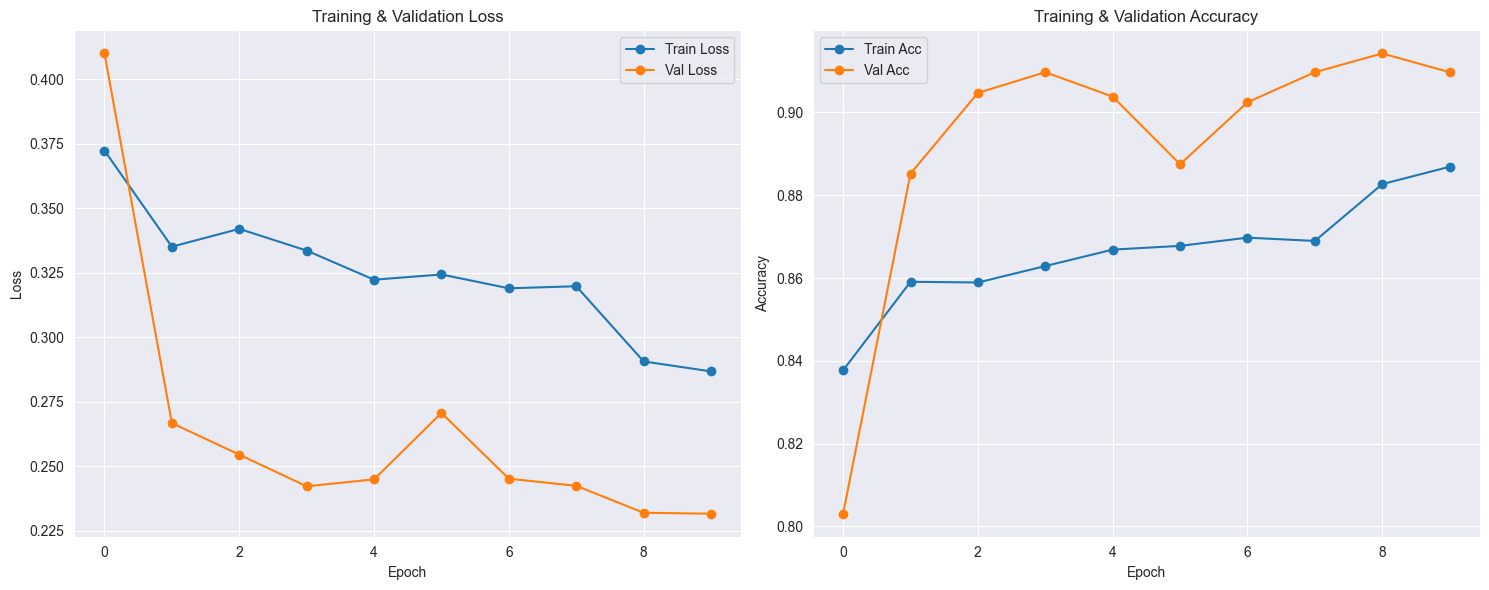

In [9]:
def plot_training_metrics(trainer):
    # 1. Download the path from trainer
    metrics_path = f"{trainer.logger.log_dir}/metrics.csv"
    
    # 2. Data loading
    metrics = pd.read_csv(metrics_path)
    
    # 3. Aggregating by epoch
    metrics_epoch = metrics.groupby("epoch").mean(numeric_only=True)
    
    # 4. Rysowanie
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot A: Loss
    if 'train_loss' in metrics_epoch.columns and 'val_loss' in metrics_epoch.columns:
        axes[0].plot(metrics_epoch.index, metrics_epoch['train_loss'], label='Train Loss', marker='o')
        axes[0].plot(metrics_epoch.index, metrics_epoch['val_loss'], label='Val Loss', marker='o')
        axes[0].set_title('Training & Validation Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)
    
    # Plot B: Accuracy
    if 'train_acc' in metrics_epoch.columns and 'val_acc' in metrics_epoch.columns:
        axes[1].plot(metrics_epoch.index, metrics_epoch['train_acc'], label='Train Acc', marker='o')
        axes[1].plot(metrics_epoch.index, metrics_epoch['val_acc'], label='Val Acc', marker='o')
        axes[1].set_title('Training & Validation Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# Plot training metrics
plot_training_metrics(trainer)

## 7. Testing process

In [10]:
results = trainer.test(model, datamodule=dm, ckpt_path='best')

Restoring states from the checkpoint path at C:\Users\Mateusz\Documents\ML_testing\Neural-Classification-of-Erythrocyte-Anomalies\checkpoints\malaria-resnet-epoch=09-val_loss=0.23.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at C:\Users\Mateusz\Documents\ML_testing\Neural-Classification-of-Erythrocyte-Anomalies\checkpoints\malaria-resnet-epoch=09-val_loss=0.23.ckpt


--- Data Module Setup Complete ---
Train samples: 17636 (Augmented)
Val samples:   2204 (Clean)
Test samples:  2206 (Clean)
Classes:       ['negative', 'positive']


C:\Users\Mateusz\Documents\ML_testing\Neural-Classification-of-Erythrocyte-Anomalies\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing DataLoader 0: 100%|██████████| 276/276 [00:06<00:00, 40.33it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9070716500282288
         test_f1            0.9069957733154297
        test_loss           0.24158616364002228
     test_precision          0.907642126083374
       test_recall          0.9068610072135925
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
